In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir /content/faces_project

In [3]:
# /content/drive/MyDrive/archive.zip
!unzip /content/drive/MyDrive/archive.zip -d /content/faces_project

Streaming output truncated to the last 5000 lines.
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_76.jpg  
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_77.jpg  
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_78.jpg  
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_79.jpg  
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_8.jpg  
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_80.jpg  
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_81.jpg  
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_82.jpg  
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_83.jpg  
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_84.jpg  
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_85.jpg  
  inflating: /content/faces_project/Faces/Faces/Alexandra Daddario_86.jpg  
  inflating: /content/faces_project/Fa

In [4]:
!pip install face_recognition==1.3.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=d1c7264e3438ef14f6e6ada5cd965fba279e75036ba191dcd8e677a142a91508
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [5]:
import face_recognition
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [6]:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [28]:
import pandas as pd
df=pd.read_csv("/content/faces_project/Dataset.csv")

In [29]:
df.head()

,id,label
0,Robert Downey Jr_87.jpg,Robert Downey Jr
1,Lisa Kudrow_64.jpg,Lisa Kudrow
2,Ellen Degeneres_34.jpg,Ellen Degeneres
3,Billie Eilish_3.jpg,Billie Eilish
4,Hrithik Roshan_35.jpg,Hrithik Roshan


In [30]:
df.shape

(2562, 2)

In [31]:
df.label.value_counts().to_frame()

,count
label,
Brad Pitt,120
Vijay Deverakonda,115
Robert Downey Jr,113
Hugh Jackman,112
Jessica Alba,108
Henry Cavill,106
Natalie Portman,105
Priyanka Chopra,102
Hrithik Roshan,101


/tmp/ipython-input-2809008230.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=names.index, x=names.values, palette='viridis')


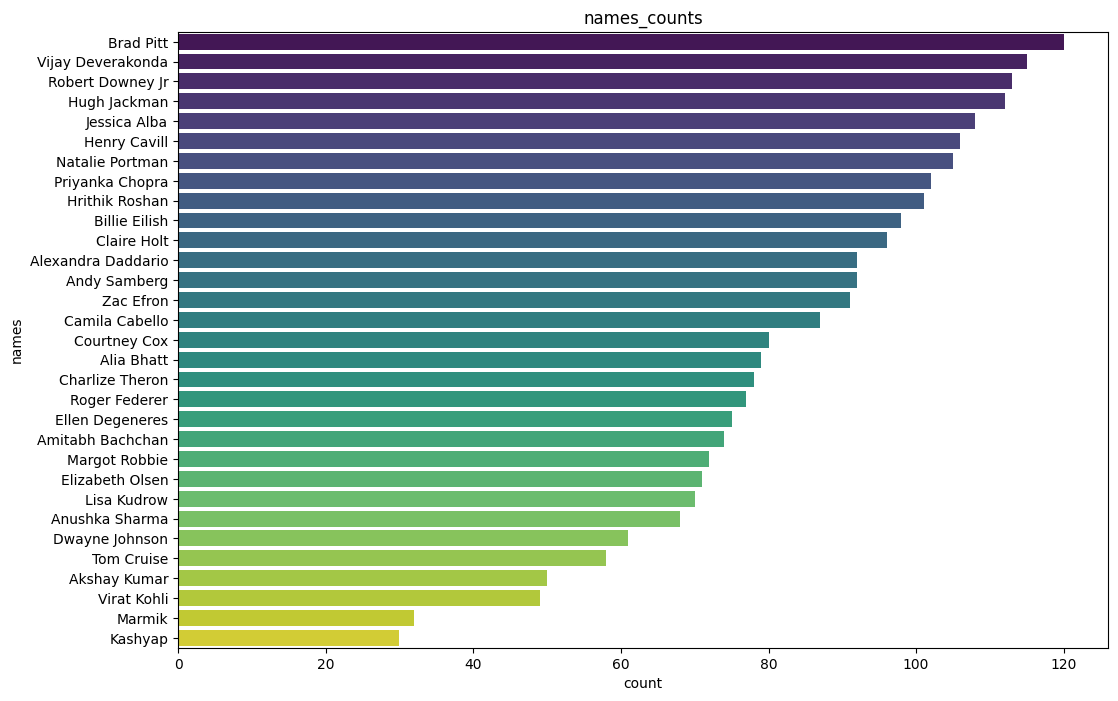

In [32]:
names=df.label.value_counts()
plt.figure(figsize=(12, 8))
sns.barplot(y=names.index, x=names.values, palette='viridis')
plt.title('names_counts')
plt.ylabel('names')
plt.xlabel('count')
plt.show()

In [7]:
dirpath = "/content/faces_project/Original Images/Original Images"

In [8]:
def create_dataset(dirpath):
    images = []
    labels = []

    for img_path in Path(dirpath).glob("**/*.jpg"):
        label = img_path.parent.name
        images.append(img_path)
        labels.append(label)

    print("✅ Total images:", len(images))
    print("✅ Total classes:", len(set(labels)))
    return images, labels

images, labels = create_dataset(dirpath)


✅ Total images: 2562
✅ Total classes: 31


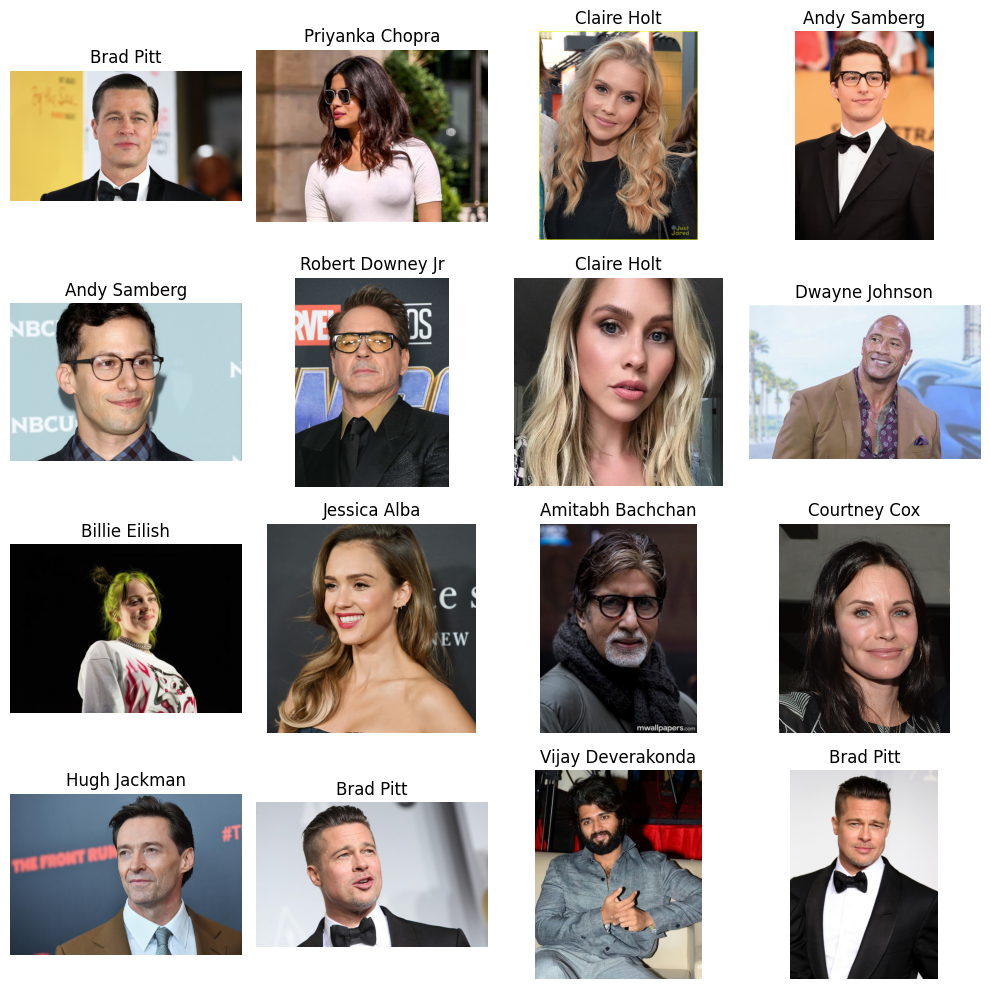

In [9]:
def show_samples(images, labels):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for ax in axes.flat:
        idx = np.random.randint(0, len(images))
        img = cv2.imread(str(images[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(labels[idx])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(images, labels)

In [10]:
X = []
y = []

for img_path in tqdm(images):
    img = face_recognition.load_image_file(img_path)
    # استخدم HOG (CPU) بدل CNN (GPU)
    locations = face_recognition.face_locations(img, model="hog")

    # نستخدم الصور اللي فيها وجه واحد فقط
    if len(locations) != 1:
        continue

    encoding = face_recognition.face_encodings(img, locations, num_jitters=1)[0]
    X.append(encoding)
    y.append(img_path.parent.name)

X = np.array(X)
y = np.array(y)

print("✅ Encodings extracted:", len(X))

100%|██████████| 2562/2562 [49:12<00:00,  1.15s/it]

✅ Encodings extracted: 2499


In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
model = KNeighborsClassifier(
    n_neighbors=2,
    weights='distance',
    metric='euclidean'
)

In [13]:
model.fit(x_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=2, weights='distance')

In [14]:
y_pred = model.predict(x_test)
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

📊 Classification Report:
                    precision    recall  f1-score   support

      Akshay Kumar       1.00      1.00      1.00        10
Alexandra Daddario       1.00      1.00      1.00        18
        Alia Bhatt       1.00      1.00      1.00        15
  Amitabh Bachchan       1.00      1.00      1.00        15
      Andy Samberg       1.00      1.00      1.00        18
    Anushka Sharma       1.00      1.00      1.00        13
     Billie Eilish       1.00      1.00      1.00        19
         Brad Pitt       1.00      1.00      1.00        24
    Camila Cabello       1.00      1.00      1.00        17
   Charlize Theron       1.00      1.00      1.00        16
       Claire Holt       1.00      1.00      1.00        19
      Courtney Cox       1.00      1.00      1.00        16
    Dwayne Johnson       1.00      1.00      1.00        12
   Elizabeth Olsen       1.00      1.00      1.00        14
   Ellen Degeneres       1.00      1.00      1.00        15
      Henry Ca

In [18]:
y_train_pred = model.predict(x_train)


from sklearn.metrics import accuracy_score
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"✅ Training Accuracy: {train_accuracy * 100:.2f}%")

✅ Training Accuracy: 100.00%


<Figure size 1000x800 with 0 Axes>

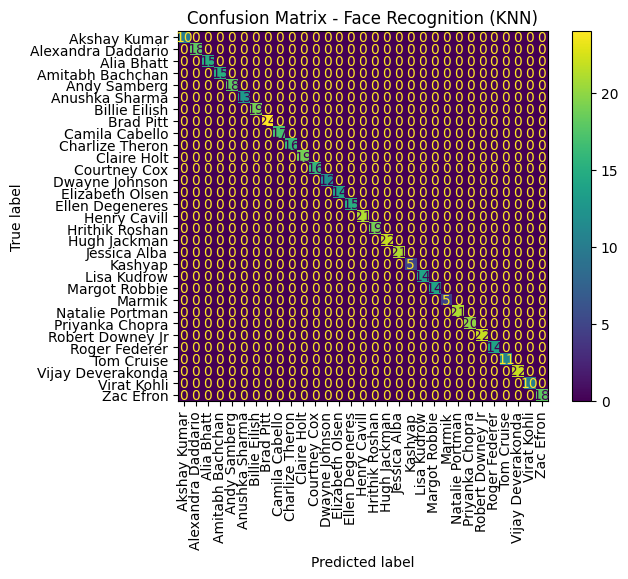

In [15]:
cm = confusion_matrix(y_test, y_pred)
labels_unique = np.unique(y)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_unique)
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix - Face Recognition (KNN)")
plt.show()

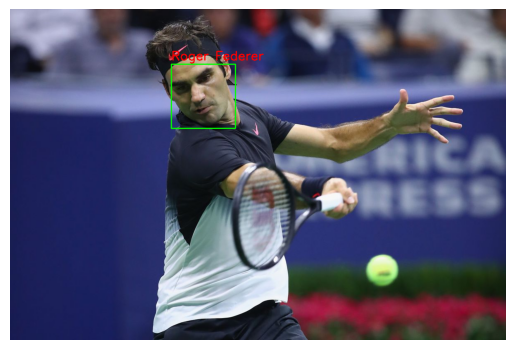

In [26]:
idx = np.random.randint(0, len(images))
test_image = face_recognition.load_image_file(images[idx])
locations = face_recognition.face_locations(test_image, model="hog")
encodings = face_recognition.face_encodings(test_image, locations, num_jitters=1)

# test_image_resized = cv2.resize(test_image, (500, 500))
# threshold = 0.6

# for (top, right, bottom, left), enc in zip(locations, encodings):
#     dist, _ = model.kneighbors([enc], n_neighbors=1)
#     if dist[0][0] < threshold:
#         name = model.predict([enc])[0]
#     else:
#         name = "Unknown"

#     cv2.rectangle(test_image_resized, (left, top), (right, bottom), (0, 255, 0), 2)
#     cv2.putText(test_image_resized, name, (left, top - 10),
#                 cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

# plt.imshow(test_image_resized)
# plt.axis("off")
# plt.show()
threshold = 0.6
for (top, right, bottom, left), enc in zip(locations, encodings):
    dist, _ = model.kneighbors([enc], n_neighbors=1)
    if dist[0][0] < threshold:
        name = model.predict([enc])[0]
    else:
        name = "Unknown"


    cv2.rectangle(test_image, (left, top), (right, bottom), (0, 255, 0), 2)
    cv2.putText(test_image, name, (left, top - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

plt.imshow(test_image)
plt.axis("off")
plt.show()

In [27]:
!pip install joblib

import joblib

joblib.dump(model, "face_recognition_model.joblib")
print("✅ Model saved as face_recognition_model.joblib")

✅ Model saved as face_recognition_model.joblib
